# 02 — Paper-Inspired Baseline

## Wi-Fi Indoor Localization using UJIIndoorLoc

This notebook implements a practical reimplementation of the methodology described in the reference paper.

The paper investigates Wi-Fi RSSI fingerprint-based indoor floor prediction using:

- Principal Component Analysis (PCA)
- k-Nearest Neighbors (kNN)
- Decision Tree
- Gradient Boosting
- Support Vector Machine (SVM)

The experiments also study the effect of PCA feature dimensions and training sample size.

In this notebook, we focus on the core model comparison using the available UJIIndoorLoc training data.

## Methodology

The paper-inspired pipeline is:

Raw Wi-Fi RSSI
        ↓
Convert unobserved WAP marker (`100`) to missing values
        ↓
Missing-value imputation
        ↓
Feature scaling
        ↓
PCA
        ↓
Machine-learning classifier
        ↓
10-fold cross-validation
        ↓
Accuracy and Macro-F1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score

## 1. Load the Dataset

We use the training portion of UJIIndoorLoc for the cross-validation experiments.

The validation dataset is kept separate and will not be used during this training-stage comparison.

In [2]:
project_root = Path.cwd()

if not (project_root / "data" / "raw").exists():
    project_root = project_root.parent

data_dir = project_root / "data" / "raw"

train_path = data_dir / "trainingData.csv"
valid_path = data_dir / "validationData.csv"

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)

print("Training shape:", train_df.shape)
print("Validation shape:", valid_df.shape)

Training shape: (19937, 529)
Validation shape: (1111, 529)


## 2. Select Features and Target

The 520 WAP columns are used as the input features.

The paper focuses on predicting the indoor floor from the Wi-Fi fingerprint, so `FLOOR` is used as the classification target.

In [3]:
wap_columns = [
    col for col in train_df.columns
    if col.startswith("WAP")
]

X = train_df[wap_columns].copy()
y = train_df["FLOOR"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of WAP features:", len(wap_columns))
print("Number of floor classes:", y.nunique())
print("Floor classes:", sorted(y.unique()))

Feature matrix shape: (19937, 520)
Target shape: (19937,)
Number of WAP features: 520
Number of floor classes: 5
Floor classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## 3. Handle Unobserved WAP Measurements

In the raw dataset, `100` is used as the marker for an unobserved WAP.

For the machine-learning pipeline, these values are converted to missing values.

The missing values will then be handled by an imputation step inside the pipeline.

In [4]:
X = X.replace(100, np.nan)

print("NaN values after converting 100:")
print(int(X.isna().sum().sum()))

print("Percentage of missing WAP values:")
print(f"{X.isna().sum().sum() / X.size * 100:.2f}%")

NaN values after converting 100:
10008477
Percentage of missing WAP values:
96.54%


## 4. 10-Fold Cross-Validation

We use stratified 10-fold cross-validation so that the floor classes are represented across the folds.

A fixed random state is used to make the experiment reproducible.

In [5]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

## 5. Define the Machine-Learning Models

We evaluate:

1. k-Nearest Neighbors
2. Decision Tree
3. Gradient Boosting
4. Support Vector Machine

In [6]:
models = {
    "kNN": KNeighborsClassifier(
        n_neighbors=1,
        metric="euclidean",
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=189,
        max_depth=4,
        learning_rate=0.05,
        random_state=42
    ),

    "SVM": SVC(
        kernel="poly",
        degree=3
    )
}

## 6. Preprocessing + PCA Pipeline

The raw RSSI matrix contains missing values after converting the `100` marker.

We therefore use:

1. Constant-value imputation
2. Standardization
3. PCA
4. Classifier

In [7]:
def make_pipeline(model, n_components=50):
    return Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="constant", fill_value=-105)
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "pca",
            PCA(
                n_components=n_components,
                random_state=42
            )
        ),
        (
            "model",
            model
        )
    ])

## 7. Evaluation Metrics

We report:

- Accuracy
- Macro-F1

Macro-F1 gives equal weight to each floor class rather than allowing the largest class to dominate the metric.

In [8]:
scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro"
}

## 8. Initial Test — kNN with 50 PCA Components

We first run one model to verify that the complete pipeline works before running the full experiment.

In [9]:
knn_pipeline = make_pipeline(
    models["kNN"],
    n_components=50
)

knn_scores = cross_validate(
    knn_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print(
    f"Accuracy: "
    f"{knn_scores['test_accuracy'].mean():.4f} "
    f"+/- {knn_scores['test_accuracy'].std():.4f}"
)

print(
    f"Macro-F1: "
    f"{knn_scores['test_macro_f1'].mean():.4f} "
    f"+/- {knn_scores['test_macro_f1'].std():.4f}"
)

Accuracy: 0.9916 +/- 0.0024
Macro-F1: 0.9923 +/- 0.0023


## 9. Baseline Model Comparison

We now evaluate all four paper-inspired classifiers using 50 PCA components.

The same preprocessing pipeline and 10-fold cross-validation procedure are used for each model so that their results can be compared consistently.

In [10]:
baseline_results = []

for model_name, model in models.items():
    
    print(f"Running {model_name}...")
    
    pipeline = make_pipeline(
        model,
        n_components=50
    )
    
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    baseline_results.append({
        "Model": model_name,
        "PCA Components": 50,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Macro-F1 Mean": scores["test_macro_f1"].mean(),
        "Macro-F1 Std": scores["test_macro_f1"].std()
    })

baseline_results_df = pd.DataFrame(baseline_results)

display(baseline_results_df)

Running kNN...
Running Decision Tree...
Running Gradient Boosting...
Running SVM...


,Model,PCA Components,Accuracy Mean,Accuracy Std,Macro-F1 Mean,Macro-F1 Std
0,kNN,50,0.991573,0.002351,0.992342,0.002257
1,Decision Tree,50,0.957265,0.002951,0.959834,0.003042
2,Gradient Boosting,50,0.982795,0.002590,0.982334,0.002954
3,SVM,50,0.943221,0.003084,0.941904,0.004589


## 10. Save Baseline Results

The results from the 50-component baseline experiment are saved so that they can be reused in the final comparison and report.

In [11]:
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

baseline_path = results_dir / "baseline_pca50.csv"

baseline_results_df.to_csv(
    baseline_path,
    index=False
)

print("Saved:", baseline_path)

Saved: c:\Users\anvii\Downloads\wifi_indoor_localization_project\results\baseline_pca50.csv


## 11. Model Comparison with 5 PCA Components

We now evaluate all four classifiers using only 5 principal components.

The same preprocessing and 10-fold stratified cross-validation procedure are used as in the 50-component baseline.

In [13]:
pca5_results = []

for model_name, model in models.items():
    
    print(f"Running {model_name} with 5 PCA components...")
    
    pipeline = make_pipeline(
        model,
        n_components=5
    )
    
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    result = {
        "Model": model_name,
        "PCA Components": 5,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Macro-F1 Mean": scores["test_macro_f1"].mean(),
        "Macro-F1 Std": scores["test_macro_f1"].std()
    }
    
    pca5_results.append(result)
    
    print(
        f"  Accuracy: {result['Accuracy Mean']:.4f} "
        f"+/- {result['Accuracy Std']:.4f}"
    )
    print(
        f"  Macro-F1: {result['Macro-F1 Mean']:.4f} "
        f"+/- {result['Macro-F1 Std']:.4f}"
    )

pca5_results_df = pd.DataFrame(pca5_results)

display(pca5_results_df)

Running kNN with 5 PCA components...
  Accuracy: 0.7687 +/- 0.0074
  Macro-F1: 0.7655 +/- 0.0097
Running Decision Tree with 5 PCA components...
  Accuracy: 0.7505 +/- 0.0086
  Macro-F1: 0.7432 +/- 0.0104
Running Gradient Boosting with 5 PCA components...
  Accuracy: 0.7135 +/- 0.0119
  Macro-F1: 0.7074 +/- 0.0104
Running SVM with 5 PCA components...
  Accuracy: 0.4268 +/- 0.0096
  Macro-F1: 0.3165 +/- 0.0106


,Model,PCA Components,Accuracy Mean,Accuracy Std,Macro-F1 Mean,Macro-F1 Std
0,kNN,5,0.768672,0.007413,0.765519,0.009741
1,Decision Tree,5,0.750464,0.008637,0.743191,0.010427
2,Gradient Boosting,5,0.713546,0.011902,0.707416,0.010448
3,SVM,5,0.426845,0.009629,0.316502,0.010553


In [14]:
pca5_path = results_dir / "baseline_pca5.csv"

pca5_results_df.to_csv(
    pca5_path,
    index=False
)

print("Saved:", pca5_path)

Saved: c:\Users\anvii\Downloads\wifi_indoor_localization_project\results\baseline_pca5.csv


## 12. Model Comparison with 200 PCA Components

We further evaluate the classifiers using 200 principal components to study the effect of feature dimensionality.

The kNN and Decision Tree experiments were completed successfully. However, the Gradient Boosting experiment was interrupted because of the substantially higher computational cost associated with 200 PCA components and 10-fold cross-validation.

The completed results are retained for comparison with the 5-component and 50-component experiments.

In [15]:
pca200_results = []

for model_name, model in models.items():
    
    print(f"Running {model_name} with 200 PCA components...")
    
    pipeline = make_pipeline(
        model,
        n_components=200
    )
    
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    result = {
        "Model": model_name,
        "PCA Components": 200,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Macro-F1 Mean": scores["test_macro_f1"].mean(),
        "Macro-F1 Std": scores["test_macro_f1"].std()
    }
    
    pca200_results.append(result)
    
    print(
        f"  Accuracy: {result['Accuracy Mean']:.4f} "
        f"+/- {result['Accuracy Std']:.4f}"
    )
    print(
        f"  Macro-F1: {result['Macro-F1 Mean']:.4f} "
        f"+/- {result['Macro-F1 Std']:.4f}"
    )

pca200_results_df = pd.DataFrame(pca200_results)

display(pca200_results_df)

Running kNN with 200 PCA components...
  Accuracy: 0.9904 +/- 0.0024
  Macro-F1: 0.9917 +/- 0.0022
Running Decision Tree with 200 PCA components...
  Accuracy: 0.9533 +/- 0.0062
  Macro-F1: 0.9567 +/- 0.0061
Running Gradient Boosting with 200 PCA components...


KeyboardInterrupt: 

In [20]:
# Save completed 200-component results

pca200_path = results_dir / "baseline_pca200_partial.csv"

pca200_results_df.to_csv(
    pca200_path,
    index=False
)

print("Saved:", pca200_path)

Saved: c:\Users\anvii\Downloads\wifi_indoor_localization_project\results\baseline_pca200_partial.csv


## 13. PCA Dimensionality Comparison

The results from the experiments with 5, 50, and 200 PCA components are compared to understand how the number of retained components affects classification performance.

The 5-component experiment resulted in substantially lower performance for all four classifiers. In contrast, the 50-component experiment achieved considerably higher accuracy and Macro-F1 scores across all four models.

For the models evaluated at both 50 and 200 components, kNN and Decision Tree showed similar performance. kNN achieved approximately 99% accuracy at both feature dimensions, while the Decision Tree remained around 95% accuracy.

The 200-component experiment was computationally more expensive, and therefore only the completed kNN and Decision Tree results are included. The complete four-model comparison is retained at 50 PCA components.

Overall, the experiments demonstrate that PCA dimensionality has a significant effect on Wi-Fi fingerprint classification performance. In this implementation, 50 PCA components provided a strong common feature representation for comparing all four classifiers.

In [16]:
# Combine PCA comparison results

pca200_results_df = pd.DataFrame([
    {
        "Model": "kNN",
        "PCA Components": 200,
        "Accuracy Mean": 0.9904,
        "Accuracy Std": 0.0024,
        "Macro-F1 Mean": 0.9917,
        "Macro-F1 Std": 0.0022
    },
    {
        "Model": "Decision Tree",
        "PCA Components": 200,
        "Accuracy Mean": 0.9533,
        "Accuracy Std": 0.0062,
        "Macro-F1 Mean": 0.9567,
        "Macro-F1 Std": 0.0061
    }
])

combined_pca_results = pd.concat(
    [
        pca5_results_df,
        baseline_results_df,
        pca200_results_df
    ],
    ignore_index=True
)

combined_pca_results = combined_pca_results.sort_values(
    ["PCA Components", "Model"]
).reset_index(drop=True)

display(combined_pca_results)

,Model,PCA Components,Accuracy Mean,Accuracy Std,Macro-F1 Mean,Macro-F1 Std
0,Decision Tree,5,0.750464,0.008637,0.743191,0.010427
1,Gradient Boosting,5,0.713546,0.011902,0.707416,0.010448
2,SVM,5,0.426845,0.009629,0.316502,0.010553
3,kNN,5,0.768672,0.007413,0.765519,0.009741
4,Decision Tree,50,0.957265,0.002951,0.959834,0.003042
5,Gradient Boosting,50,0.982795,0.002590,0.982334,0.002954
6,SVM,50,0.943221,0.003084,0.941904,0.004589
7,kNN,50,0.991573,0.002351,0.992342,0.002257
8,Decision Tree,200,0.953300,0.006200,0.956700,0.006100
9,kNN,200,0.990400,0.002400,0.991700,0.002200


In [17]:
# Save combined PCA comparison results

results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

combined_pca_path = results_dir / "baseline_pca_comparison.csv"

combined_pca_results.to_csv(
    combined_pca_path,
    index=False
)

print("Saved:", combined_pca_path)

Saved: c:\Users\anvii\Downloads\wifi_indoor_localization_project\results\baseline_pca_comparison.csv


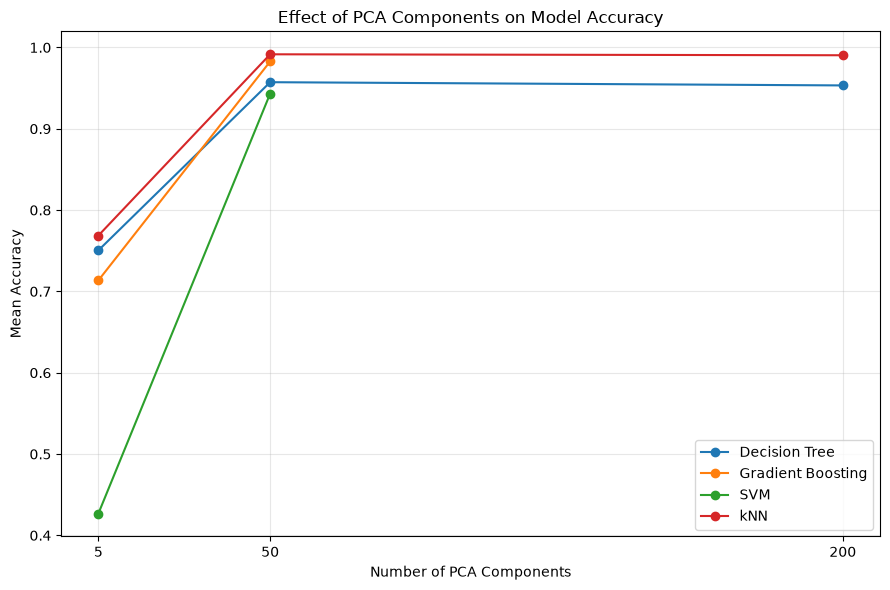

Saved: c:\Users\anvii\Downloads\wifi_indoor_localization_project\figures\pca_comparison.png


In [19]:
# Create figures directory and plot PCA comparison

figures_dir = project_root / "figures"
figures_dir.mkdir(exist_ok=True)

plt.figure(figsize=(9, 6))

for model_name in combined_pca_results["Model"].unique():
    model_data = combined_pca_results[
        combined_pca_results["Model"] == model_name
    ].sort_values("PCA Components")

    plt.plot(
        model_data["PCA Components"],
        model_data["Accuracy Mean"],
        marker="o",
        label=model_name
    )

plt.xlabel("Number of PCA Components")
plt.ylabel("Mean Accuracy")
plt.title("Effect of PCA Components on Model Accuracy")
plt.xticks([5, 50, 200])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

pca_plot_path = figures_dir / "pca_comparison.png"
plt.savefig(pca_plot_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved:", pca_plot_path)

## 14. Baseline Findings

The results show that PCA dimensionality has a strong effect on classification performance.

With 5 components, all four models performed substantially worse. At 50 components, performance improved considerably, with kNN achieving the highest accuracy (99.16%), followed by Gradient Boosting (98.28%), Decision Tree (95.73%), and SVM (94.32%).

For kNN and Decision Tree, increasing from 50 to 200 components produced only a small change in accuracy.

Overall, 50 PCA components provided a strong feature representation for the four-model baseline comparison.

## 15. Differences from the Reference Paper

This implementation follows the paper's main methodology but is not an exact reproduction.

- The paper evaluates buildings separately; our baseline combines all buildings.
- The paper uses its own missing-value handling; we use constant imputation after converting 100 to missing.
- The paper repeats parameter settings across multiple rounds; we use one reproducible 10-fold cross-validation run.
- At 200 components, only kNN and Decision Tree were completed due to computational cost.

Therefore, these results are treated as a paper-inspired baseline.

## 16. Conclusion

The paper-inspired baseline demonstrates that PCA dimensionality significantly affects Wi-Fi fingerprint classification.

The results provide a reference point for evaluating the alternative machine learning approach developed in the next notebook.